In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [121]:
df = pd.read_csv('2025_Airbnb_NYC_listings.csv')
df

,Unnamed: 0,id,source,name,description,neighborhood_overview,host_id,host_name,host_since,host_location,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,0,36121,city scrape,Lg Rm in Historic Prospect Heights,Cozy space share in the heart of a great neigh...,Full of tree-lined streets and beautiful brown...,62165,Michael,2009-12-11,"New York, NY",...,5.00,5.00,5.00,NaN,f,1,0,1,0,0.05
1,1,36647,city scrape,"1 Bedroom & your own Bathroom, Elevator Apartment",Private bedroom with your own bathroom in a 2 ...,"Manhattan, SE corner of 2nd Ave/ E. 110th street",157798,Irene,2010-07-04,"New York, NY",...,4.90,4.38,4.71,NaN,f,1,0,1,0,0.58
2,2,38663,city scrape,Luxury Brownstone in Boerum Hill,"Beautiful, large home in great hipster neighbo...","diverse, lively, hip, cool: loaded with restau...",165789,Sarah,2010-07-13,"New York, NY",...,4.88,4.86,4.62,OSE-STRREG-0001784,f,1,0,1,0,0.28
3,3,38833,city scrape,Spectacular West Harlem Garden Apt,This is a very large and unique space. An inc...,West Harlem is now packed with great restauran...,166532,Matthew,2010-07-14,"New York, NY",...,4.96,4.79,4.82,OSE-STRREG-0000476,f,1,1,0,0,1.36
4,4,39282,city scrape,“Work-from-home” from OUR home.,*Monthly Discount will automatically apply <br...,THE NEIGHBORHOOD:<br />Our apartment is locate...,168525,Gustavo,2010-07-16,"New York, NY",...,4.88,4.85,4.78,OSE-STRREG-0001150,f,2,0,2,0,1.54
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22303,37429,1366333532374850165,city scrape,Beautiful 1-Bed Apt in Harlem!,Welcome to your temporary home in the vibrant ...,NaN,40019013,Cecilia,2015-07-30,"New York, NY",...,NaN,NaN,NaN,NaN,f,1,0,1,0,NaN
22304,37430,1366717321390111215,city scrape,Private Room w/ Ensuite Bath H,Stylish Private Rooms w/ En-Suite Baths in Bro...,NaN,483056418,Kristina,2022-10-10,"New York, NY",...,NaN,NaN,NaN,NaN,f,24,0,24,0,NaN
22305,37431,1366721904709517353,city scrape,2 Bedroom on East Side,Located in the Murray Hill area and occupies a...,NaN,30283594,Global Luxury Suites,2015-03-30,"Hawthorne, NJ",...,NaN,NaN,NaN,NaN,f,48,48,0,0,NaN
22306,37432,1366722692755341871,city scrape,Stylish 2Bd near Bryant Park,Enjoy everything the city has to offer while l...,NaN,407304997,Boomerang,2021-06-15,"New York, NY",...,NaN,NaN,NaN,NaN,t,25,25,0,0,NaN


# 데이터 구조 확인

In [ ]:
df.info()
df.head()
df.describe()

# 필요없는 인덱스 제거
df=df.drop(columns=['Unnamed: 0'])

<class 'pandas.DataFrame'>
RangeIndex: 22308 entries, 0 to 22307
Data columns (total 73 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Unnamed: 0                                    22308 non-null  int64  
 1   id                                            22308 non-null  int64  
 2   source                                        22308 non-null  str    
 3   name                                          22308 non-null  str    
 4   description                                   21903 non-null  str    
 5   neighborhood_overview                         12262 non-null  str    
 6   host_id                                       22308 non-null  int64  
 7   host_name                                     22288 non-null  str    
 8   host_since                                    22288 non-null  str    
 9   host_location                                 17025 non-null  str    
 1

# 컬럼 확인

In [ ]:
df.columns

Index(['id', 'source', 'name', 'description', 'neighborhood_overview',
       'host_id', 'host_name', 'host_since', 'host_location', 'host_about',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'calendar_updated', 'has_availability',
       'availability_30', 'availability_60', 'availability_90',
       'availability_365',

In [141]:
df.dtypes
df.dtypes.value_counts()

str               27
float64           24
int64             17
datetime64[us]     1
Name: count, dtype: int64

#### 범주형 컬럼

In [142]:
df.select_dtypes(include='object').columns

C:\Users\yhb05\AppData\Local\Temp\ipykernel_50972\3732952691.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').columns


Index(['source', 'description', 'neighborhood_overview', 'host_since',
       'host_location', 'host_about', 'host_response_time',
       'host_response_rate', 'host_acceptance_rate', 'host_is_superhost',
       'host_neighbourhood', 'host_verifications', 'host_has_profile_pic',
       'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed',
       'neighbourhood_group_cleansed', 'property_type', 'room_type',
       'bathrooms_text', 'amenities', 'price', 'has_availability',
       'calendar_last_scraped', 'first_review', 'license', 'instant_bookable'],
      dtype='str')

#### 수치형 컬럼

In [143]:
df.select_dtypes(include=['int64','float64']).columns

Index(['host_listings_count', 'host_total_listings_count', 'latitude',
       'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'calendar_updated', 'availability_30',
       'availability_60', 'availability_90', 'availability_365',
       'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d',
       'availability_eoy', 'number_of_reviews_ly', 'estimated_occupancy_l365d',
       'estimated_revenue_l365d', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_scores_value',
       'calculated_host_listings_count',
       'calculated_host_listings_count_entire_homes',
       'calculated_host_listings_count_priv

#### 날짜형 컬럼

In [188]:
date_cols = df.select_dtypes(include='datetime').columns
print("날짜형 컬럼:", date_cols)


# datetime으로 변환
df[date_cols] = df[date_cols].apply(pd.to_datetime,errors='coerce')

df[date_cols].dtypes

날짜형 컬럼: Index(['host_since', 'calendar_last_scraped', 'first_review', 'last_review'], dtype='str')


host_since               datetime64[us]
calendar_last_scraped    datetime64[us]
first_review             datetime64[us]
last_review              datetime64[us]
dtype: object

# 결측치 확인

In [145]:
df.isnull().sum().sort_values(ascending=False)

calendar_updated                                22308
license                                         17845
neighbourhood                                   10046
neighborhood_overview                           10046
host_about                                       8917
                                                ...  
instant_bookable                                    0
calculated_host_listings_count_entire_homes         0
calculated_host_listings_count                      0
calculated_host_listings_count_shared_rooms         0
calculated_host_listings_count_private_rooms        0
Length: 69, dtype: int64

In [153]:
# 전체 컬럼 결측 비율
# 결측치 개수
missing_count = df.isnull().sum()

# 결측 비율
missing_ratio = df.isnull().sum() / len(df) * 100
missing_ratio = missing_ratio[missing_ratio > 0].sort_values(ascending=False)

missing_df.head(15)

,missing_count,missing_ratio(%)
calendar_updated,22308,100.000000
license,17845,79.993724
neighbourhood,10046,45.033172
neighborhood_overview,10046,45.033172
host_about,8917,39.972207
review_scores_location,6799,30.477855
review_scores_checkin,6798,30.473373
review_scores_communication,6798,30.473373
last_review,6798,30.473373
review_scores_cleanliness,6798,30.473373


In [148]:
# 필요 없는 컬럼 제거
df = df.drop(columns=['Unnamed: 0','id','host_id','name','host_name'], errors='ignore')

In [160]:
# price 처리
df['price'].dtype

# '$'와 ',' 제거 후 float 변환
df['price'] = df['price'].replace("[$,]", "", regex=True)  
df['price'] = pd.to_numeric(df['price'], errors='coerce') 

# 0원 제거
df = df[df['price'] > 0] 


df['price'].describe()

count    22308.000000
mean       213.835216
std        427.599435
min          7.000000
25%         85.000000
50%        140.000000
75%        240.000000
max      20000.000000
Name: price, dtype: float64

# price 컬럼 처리

In [165]:
# price 처리
df['price'].dtype

df['price'].isnull().sum()

# '$'와 ',' 제거 후 float 변환
df['price'] = df['price'].replace("[$,]", "", regex=True)  
df['price'] = pd.to_numeric(df['price'], errors='coerce') 

# 0원 제거
df = df[df['price'] > 0] 


df['price'].describe()

count    22308.000000
mean       213.835216
std        427.599435
min          7.000000
25%         85.000000
50%        140.000000
75%        240.000000
max      20000.000000
Name: price, dtype: float64

In [184]:
# price 로그변환
df["price_log1p"] = np.log1p(df["price"])  # log(1+Fare)
df["price_log1p"]

0        5.303305
1        4.418841
2        6.641182
3        4.941642
4        4.875197
           ...   
22303    4.290459
22304    4.077537
22305    5.703782
22306    5.303305
22307    4.077537
Name: price_log1p, Length: 22308, dtype: float64

In [189]:
# 가격이 20000인 숙소 
df[df["price"]  >=  20000]

,source,description,neighborhood_overview,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,...,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,days_since_last_review,occupancy_rate,price_log1p
14131,city scrape,The 640 square foot Howard Suite at 11 Howard ...,NaN,2020-01-10,"Oakland, CA","Hi, welcome to Suiteness! My name is Jeanna a...",within an hour,99%,89%,f,...,Exempt,t,45,0,45,0,NaN,NaN,0.0,9.903538
14132,city scrape,The 640 square foot Howard Suite at 11 Howard ...,NaN,2020-01-10,"Oakland, CA","Hi, welcome to Suiteness! My name is Jeanna a...",within an hour,99%,89%,f,...,Exempt,t,45,0,45,0,NaN,NaN,0.0,9.903538
14133,city scrape,"Revel in a private, rooftop terrace with views...",NaN,2020-01-10,"Oakland, CA","Hi, welcome to Suiteness! My name is Jeanna a...",within an hour,99%,89%,f,...,Exempt,t,45,0,45,0,NaN,NaN,0.0,9.903538


# 합법 불법

합법 대상 숙소

In [1]:
target_df = df[(df["room_type"] == "Entire home/apt") & (df["minimum_nights"] < 30)]
target_df

NameError: name 'df' is not defined

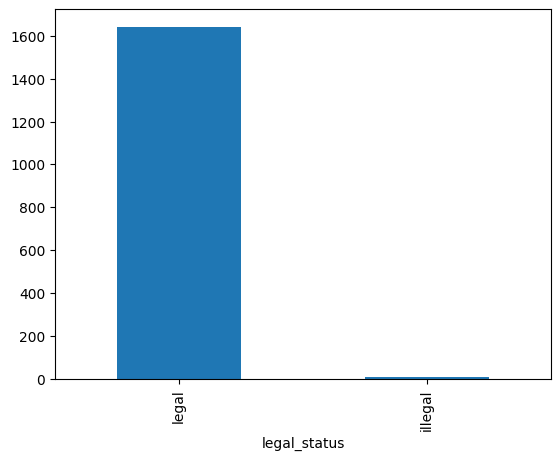

In [ ]:
# license 결측처리
target_df["license"].isnull().sum()

# 불법 / 합법 구분 변수 생성 LLM 도움..^^
target_df["legal_status"] = target_df["license"].apply(
    lambda x: "illegal" if pd.isnull(x) else "legal"
)

# 합법 vs 불법 비율
target_df["legal_status"].value_counts().plot(kind="bar")
plt.show()

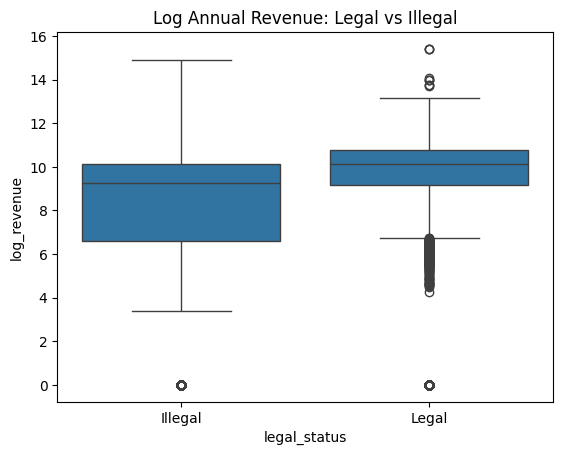

In [ ]:
target_df["log_revenue"] = np.log1p(target_df["estimated_annual_revenue"])

sns.boxplot(
    x="legal_status",
    y="log_revenue",
    data=target_df
)
plt.title("Log Annual Revenue: Legal vs Illegal")
plt.show()

- 합법 숙소의 중앙값이 더 높고 불법보다 전체적으로 위에 위치 
- 합법 숙소가 평균적으로 더 높은 연간 수익 !
- 불법 숙소는 분포가 더 넓고 아래로 퍼져있는 걸 보아하니 수익 편차가 큼
- 그에 비해ㅔ서 합법 숙소는 비교적 안정적인 수익 구조

# 어메니티

In [197]:
df['amenities_list'] = df['amenities'].str.split(', ')
df['amenities_list'].head()

0    [["Refrigerator", "Dishes and silverware", "Wi...
1    [["Oven", "Blender", "Luggage dropoff allowed"...
2    [["Portable fans", "Oven", "Baking sheet", "Fi...
3    [["Fire extinguisher", "Clothing storage: clos...
4    [["Oven", "Rice maker", "Laundromat nearby", "...
Name: amenities_list, dtype: object

In [ ]:
# 문자열을 리스트로 
import ast

df['amenities_list'] = df['amenities'].apply(lambda x: list(ast.literal_eval(x)))

In [55]:
top_30_df = pd.DataFrame(top_30, columns=["amenities", "count"])
top_30_df

,amenities,count
0,Smoke alarm,21096
1,Wifi,20577
2,Carbon monoxide alarm,19386
3,Kitchen,19122
4,Hot water,17333
5,Essentials,16548
6,Hangers,16524
7,Hair dryer,15354
8,Iron,15268
9,Air conditioning,14922


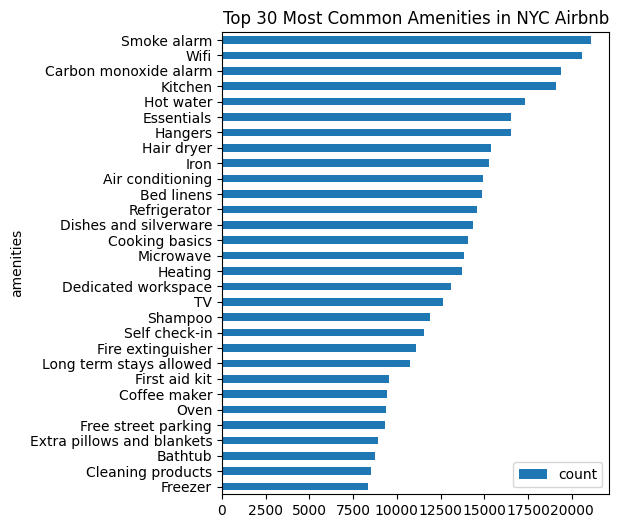

In [194]:
import matplotlib.pyplot as plt

top_30_df.sort_values("count").plot.barh(
    x="amenities",
    y="count",
    figsize=(5,6)
)

plt.title("Top 30 Most Common Amenities in NYC Airbnb")
plt.show()

# 가격 분위별(점유, 매출, 리뷰) 분석

## 가격 구간 설정 (사분위수)

In [106]:
# 가격 분위수 -> 4분위

df["price_q"] = pd.qcut(
    df["price"],
    q=4,
    labels=["Q1", "Q2", "Q3", "Q4"]
)
df["price_q"]

0        Q3
1        Q1
2        Q4
3        Q2
4        Q2
         ..
22303    Q1
22304    Q1
22305    Q4
22306    Q3
22307    Q1
Name: price_q, Length: 22308, dtype: category
Categories (4, str): ['Q1' < 'Q2' < 'Q3' < 'Q4']

### 가격 구간 별 점유율

In [166]:
df['estimated_occupancy_l365d'].dtype

dtype('int64')

In [168]:
# 점유율 = 최근 365일 동안 예약된 일수 / 365
df["occupancy_rate"] = df["estimated_occupancy_l365d"] / 365
df["occupancy_rate"].head(15)

0     0.000000
1     0.000000
2     0.000000
3     0.698630
4     0.421918
5     0.000000
6     0.493151
7     0.000000
8     0.698630
9     0.698630
10    0.164384
11    0.000000
12    0.000000
13    0.460274
14    0.000000
Name: occupancy_rate, dtype: float64

- 0은 1년 동안 예약이 없는거고 1은 일 년 내내 있는거고

<Axes: xlabel='price_q'>

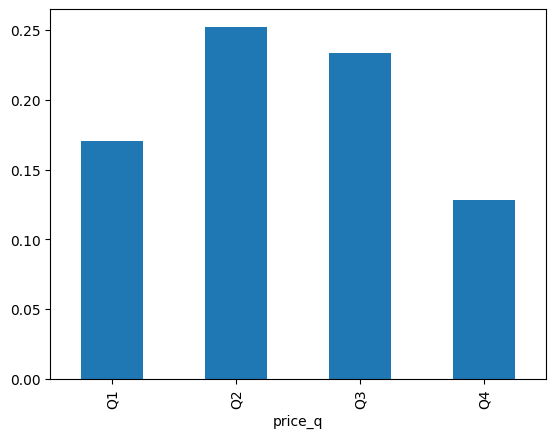

In [107]:
df.groupby("price_q")["occupancy_rate"].mean().plot(kind="bar")

- Q2>Q3>Q1>Q4 순으로 점유 높음
- Q4에서 점유 급감 => 고객층 한정적
- => 가격 탄력성 ?
- ? 왜 Q1 < Q3 ? 
    - 너무 저렴하기보다 적정한 성능과 가격인 '가성비'를  ? / 
    - 무조건 싼 제품을 찾기보다는 조금 더 돈을 쓰더라도 품질이 보장된 Q2, Q3을 선택

### 가격 구간별 최근 365일 기준 추정 매출

In [ ]:
df['estimated_revenue_l365d'].dtype

dtype('float64')

In [181]:
# 최근 365일 기준 추정 매출 = 가격 x 최근 365일 동안 예약된 일수
df['estimated_revenue_l365d'] = df['price'] * df['estimated_occupancy_l365d']
df["estimated_revenue_l365d"].head(15)

0         0.0
1         0.0
2         0.0
3     35445.0
4     20020.0
5         0.0
6     17280.0
7         0.0
8     17085.0
9     49725.0
10    17400.0
11        0.0
12        0.0
13    25200.0
14        0.0
Name: estimated_revenue_l365d, dtype: float64

- 해당 숙소의 가격이 0이거나, 1년간 예약된 일 수가 없다 ?

- 점유율 파트랑 반대 양상임
- 수익은 확실히 고가 구간에 몰려잇음
- Q4는 점유율은 낮지만 수익은 압도적, 예약률이 낮아도 단가가 높아서 매출액 자체는 1등 !
- Q1은 점유도 하위권, 수익도 꼴찌
    - 신뢰도? 아니면 도 다른 무언가 문제인가

### 가격 구간별 리뷰수

In [110]:
df.groupby("price_q")["number_of_reviews"].mean()

price_q
Q1    30.373913
Q2    44.315742
Q3    41.425582
Q4    21.350423
Name: number_of_reviews, dtype: float64

<Axes: xlabel='price_q'>

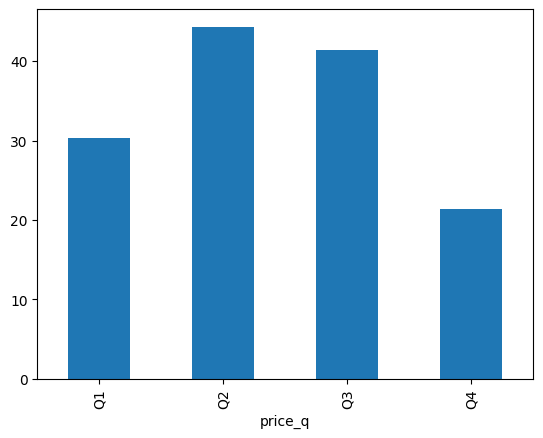

In [111]:
df.groupby("price_q")["number_of_reviews"].mean().plot(kind="bar")

- 리뷰는 일반적으로 예약건수와 상관관계 있음
- Q4는 점유, 리뷰 꼴찐데 매출은 1등임; 고효율 근데 하이엔드? 그러한,,
- Q2는 점유도 리뷰도 1등 -> 레드오션으로 경쟁 치열
    - 근데 매출은 Q3 Q4보다 훨씬 떨어짐: 효율 떨어짐
- Q3은 리뷰 2랑 비슷하고 매출도 4와 비슷 : 안정성이랑 수익 good

## 리뷰수 vs 가격 상관관계 알아보쟈,,

In [112]:
df[["price", "number_of_reviews"]].corr()

,price,number_of_reviews
price,1.000000,-0.051742
number_of_reviews,-0.051742,1.000000


- 수치가 마이너스임
- 가격 오를수록 리뷰수가 줄어는 거 아아아아아주 미세
    - 상관계수 0.2 미만이면 상관관계 거의 없다고 판단한다고 함
- 즉, 두 컬럼 독립적임
    - 리뷰수의 결정요인이 가격이 아님, 가격 말고 예약 결정에 더 큰 영향을 미치는 다른 변수? 가 있다

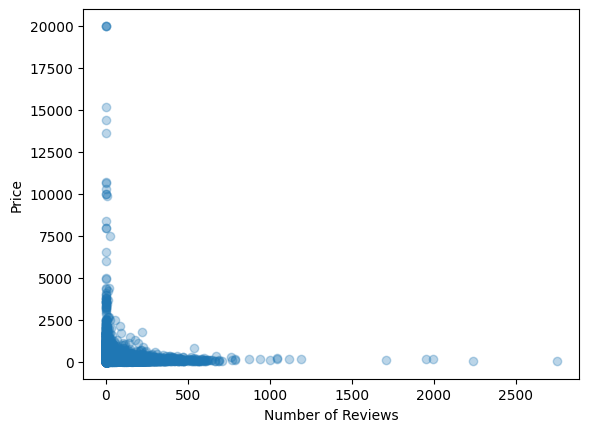

In [113]:
# 산점도로 확인 
import matplotlib.pyplot as plt

plt.scatter(df["number_of_reviews"], df["price"], alpha=0.3)
plt.xlabel("Number of Reviews")
plt.ylabel("Price")
plt.show()

 - 리뷰 많아도 저가 숙소 존재, 리뷰 적어도 고가 숙소 존재

## availability vs 가격 상관관계 차례다

In [86]:
df[["price", "availability_365"]].corr()

,price,availability_365
price,1.000000,0.038117
availability_365,0.038117,1.000000


- 마찬가지임, 비싸다고 비어있는 날이 더 많은게 아님

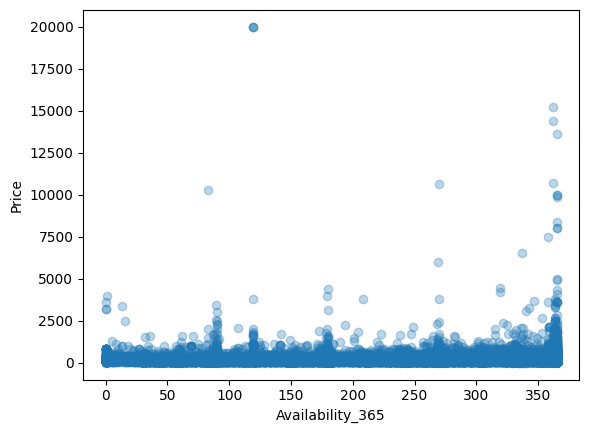

In [88]:
plt.scatter(df["availability_365"], df["price"], alpha=0.3)
plt.xlabel("Availability_365")
plt.ylabel("Price")
plt.show()

<availability는 “비어있는 날짜 수”>

값이 높으면 예약 안 되어있음
값이 낮으면 예약 많이 되어있ㅇ므

In [82]:
df.groupby("price_q")["availability_365"].mean()

price_q
Q1    230.626974
Q2    236.024053
Q3    240.176258
Q4    252.205253
Name: availability_365, dtype: float64

# 리뷰 및 수요 컬럼 전처리

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('2025_Airbnb_NYC_listings.csv')

In [18]:
# 숫자형 리뷰 및 수요 컬럼 결측치 처리
review_zero_cols = [
    'number_of_reviews',
    'number_of_reviews_ltm',
    'number_of_reviews_l30d',
    'number_of_reviews_ly',
    'reviews_per_month',
    'estimated_occupancy_l365d'
]

df[review_zero_cols] = df[review_zero_cols].fillna(0)

In [36]:
# 평점은 중앙값 대체 (0으로 처리하면 왜곡)
df['review_scores_rating'] = df['review_scores_rating'].fillna(
    df['review_scores_rating'].median()
)

### <number_of_reviews (전체 리뷰 수)>
- 누적 수요 지표
- 운영 기간이 길수록 자연스럽게 커짐
- 오래된 숙소에 유리할 듯

In [19]:
df['number_of_reviews'].describe()

count    22308.000000
mean        34.353102
std         76.783685
min          0.000000
25%          0.000000
50%          5.000000
75%         35.000000
max       2749.000000
Name: number_of_reviews, dtype: float64

In [15]:
df['number_of_reviews'].sort_values(ascending=False).head(10)

13316    2749
9458     2238
7870     1998
4986     1951
10703    1709
4979     1193
8301     1120
3241     1046
7903     1043
10773     999
Name: number_of_reviews, dtype: int64

- 평균이 중앙 값보다 훨씬 큰걸(거의 7배) 보아하니 상위 극단이 평균을 끌어올림
- 일부 숙소는 2000개도 넘고 아예 없는 숙소도 있음 => 치우침

In [ ]:
# 로그 변환 -> 치우침 완화
df['log_reviews'] = np.log1p(df['number_of_reviews'])
df['log_reviews']

0        2.302585
1        4.634729
2        3.784190
3        5.488938
4        5.616771
           ...   
22303    0.000000
22304    0.000000
22305    0.000000
22306    0.000000
22307    0.000000
Name: log_reviews, Length: 22308, dtype: float64

### <number_of_reviews_ltm (최근 12개월 리뷰 수)>
- 현재 수요를 가장 잘 반영하는 변수
- 누적 리뷰보다 훨씬 중요

### <number_of_reviews_l30d (최근 30일)>
- 단기 트렌드 지표
- 시즌성 가능

In [ ]:
# 최근에 활동한 숙소인가
df['recent_activity'] = (df['number_of_reviews_l30d'] > 0).astype(int)
df['recent_activity']

0        0
1        0
2        0
3        1
4        0
        ..
22303    0
22304    0
22305    0
22306    0
22307    0
Name: recent_activity, Length: 22308, dtype: int64

### <number_of_reviews_ly (작년 리뷰 수)>
- ltm와 거의 유사할 가능성?

In [ ]:
# 상관계수 확인
df[['number_of_reviews_ltm','number_of_reviews_ly']].corr()

,number_of_reviews_ltm,number_of_reviews_ly
number_of_reviews_ltm,1.000000,0.993216
number_of_reviews_ly,0.993216,1.000000


- 0.9 이상일아 완전한 상관관계로 사실상 중복됨
- 둘 중 하나 삭제해도 될 듯
    - number_of_reviews_ltm 을 쓰는게 어떨지 ; 최근 수요?의 의미가 더 명확하니까( 더 현재 수요 반영)

In [29]:
# number_of_reviews_ly (작년 리뷰 수) 삭제
df = df.drop(columns=['number_of_reviews_ly'], errors='ignore')
print('number_of_reviews_ly' in df.columns)

False


### <first_review (첫 리뷰 날짜)>
- 실제 예약 후 첫 리뷰로 리뷰를 남기기 시작한 시점
- 숙소가 실제 운영 시작한 날짜랑은 다른 것
    - 리뷰 시작 날짜가 진짜 운영 기간이 아니라는 것


In [30]:
# 날짜형 → datetime 변환
df['first_review'] = pd.to_datetime(df['first_review'], errors='coerce')

- 리뷰수가 해당 시점 이후부터 누적되는 특성 때문에 단순 비교 하면 오래된 숙소가 유리하게 나타남 무조건.
    - i.e. Manhattan 200개 8년/ Queens 120개 1년 => Manhattan이 많아 보이지만 연간으로 따지면 Queens가 훨씬 인기
    - 리뷰수 = 수요와 운영기간이 관계 
    - 따라서 운영기간 고려해야한다고 생각
- 그러면 단위 기간당 리뷰 수를 분석할 수 있도록 전처리?

In [ ]:
# 리뷰가 쌓일 수 있었던 기간, 숙소가 첫 리뷰 이후 얼마나 운영됐는지
df['operating_days'] = (
    pd.Timestamp("today") - df['first_review']
).dt.days
df['operating_days']

0        5563.0
1        5631.0
2        4987.0
3        5668.0
4        5694.0
          ...  
22303       NaN
22304       NaN
22305       NaN
22306       NaN
22307       NaN
Name: operating_days, Length: 22308, dtype: float64

### <last_review (마지막 리뷰 날짜)>
- 현재 활성 상태 판단 가능

### <review_scores_rating (평점)>
- 품질 지표

#### 결측을 뭐로 채울까 평균값 or 중앙값

In [43]:
df['review_scores_rating'].describe()

count    22308.000000
mean         4.762664
std          0.385530
min          1.000000
25%          4.750000
50%          4.850000
75%          4.920000
max          5.000000
Name: review_scores_rating, dtype: float64

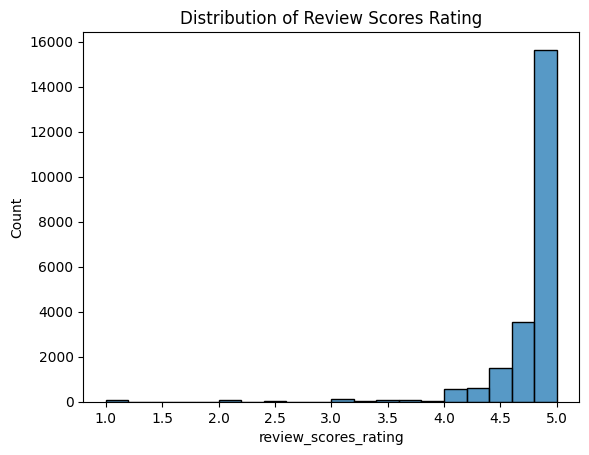

In [44]:
sns.histplot(df['review_scores_rating'], bins=20)
plt.title("Distribution of Review Scores Rating")
plt.show()

- 평점 4~5에 몰리고

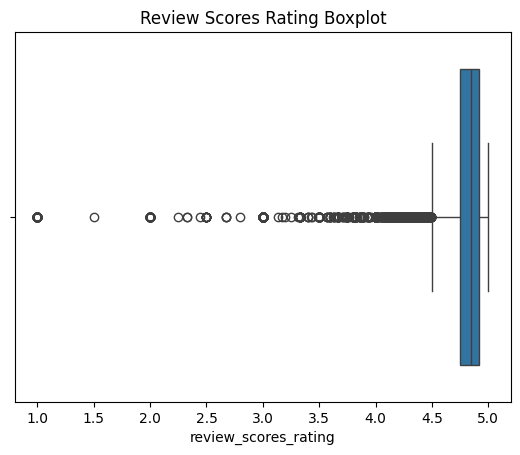

In [39]:
sns.boxplot(x=df['review_scores_rating'])
plt.title("Review Scores Rating Boxplot")
plt.show()

- 낮은 평점(아웃라이어) 존재 -> 평균 끌어내리니까 중앙값 사용이 나을거라고 판단

In [50]:
# 그래서 중앙값으로 대체 (0으로하면 왜곡 가능성)
df['review_scores_rating'] = df['review_scores_rating'].fillna(df['review_scores_rating'].median())

### <reviews_per_month (월 평균 리뷰 수)>
- 운영기간 보정된 수요

- 맨 위 결측치 처리

### <estimated_occupancy_l365d (최근 365일 예약일수)>
- 가장 직접적인 수요 지표
- 맨 위 결측치 처리

- 0~365 단위로 하면 높은건지 아닌건지 직관적인 판단이 어렵다고 생각
- 비율로 따질 수 있는 파생변수 만들면 어떨지
    - 다른 변수들과의 스케일 차이를 줄일 수 잇음

In [52]:
df['occupancy_rate'] = df['estimated_occupancy_l365d'] / 365
df['occupancy_rate']

0        0.000000
1        0.000000
2        0.000000
3        0.698630
4        0.421918
           ...   
22303    0.000000
22304    0.000000
22305    0.000000
22306    0.000000
22307    0.000000
Name: occupancy_rate, Length: 22308, dtype: float64

### <estimated_revenue_l365d (최근 365일 추정 매출)>
- 핵심 타겟이 될 수 있는 컬럼

In [53]:
df = df[df['estimated_revenue_l365d'] >= 0]

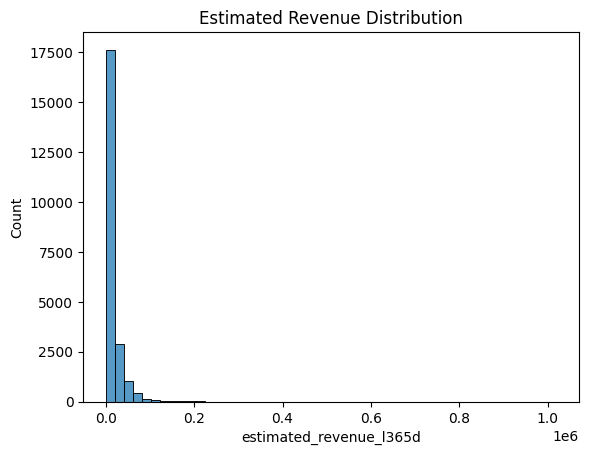

In [54]:
# 매출 분포 확인
sns.histplot(df['estimated_revenue_l365d'], bins=50)
plt.title("Estimated Revenue Distribution")
plt.show()

- 심히 비대칭임

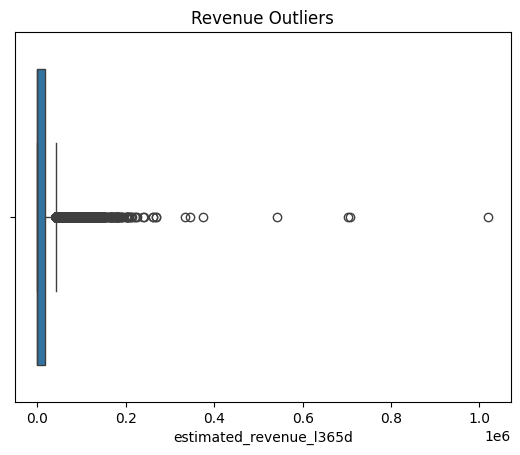

In [55]:
# 이상치
sns.boxplot(x=df['estimated_revenue_l365d'])
plt.title("Revenue Outliers")
plt.show()

In [57]:
Q1 = df['estimated_revenue_l365d'].quantile(0.25)
Q3 = df['estimated_revenue_l365d'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['estimated_revenue_l365d'] < lower) | (df['estimated_revenue_l365d'] > upper)]

print(len(outliers))

1784


In [58]:
print("전체 데이터:", len(df))
print("이상치 개수:", len(outliers))
print("이상치 비율:", len(outliers)/len(df)*100)

전체 데이터: 22308
이상치 개수: 1784
이상치 비율: 7.997131074054151


In [59]:
# 로그 변환하면 안정적
df['log_revenue'] = np.log1p(df['estimated_revenue_l365d'])

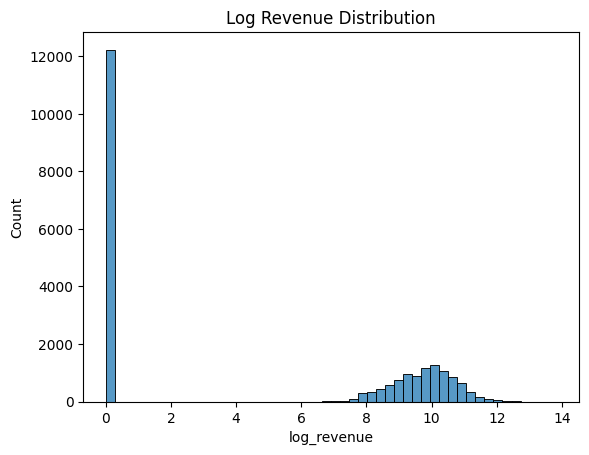

In [61]:
sns.histplot(df['log_revenue'], bins=50)
plt.title("Log Revenue Distribution")
plt.show()

In [63]:
df[['estimated_revenue_l365d','log_revenue']].describe()

,estimated_revenue_l365d,log_revenue
count,2.230800e+04,22308.000000
mean,1.190194e+04,4.409065
std,2.418692e+04,4.899624
min,0.000000e+00,0.000000
25%,0.000000e+00,0.000000
50%,0.000000e+00,0.000000
75%,1.650000e+04,9.711176
max,1.020050e+06,13.835363


로그 변환 하니 분포 값 훨씬 축소